In [18]:
from ot import sinkhorn2
from wasserstein import wasserstein
import numpy as np
import numpy.random as rand
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions import Uniform
import torch
import matplotlib.pyplot as plt

### Different Support Case

In [16]:
n = int(1e3)

x1 = MultivariateNormal(torch.zeros(1), torch.eye(1)).sample((n,))
x2 = MultivariateNormal(torch.ones(1) * 1.0, torch.eye(1)).sample((n,))

wasserstein(x1, x2)

tensor([0.9317])

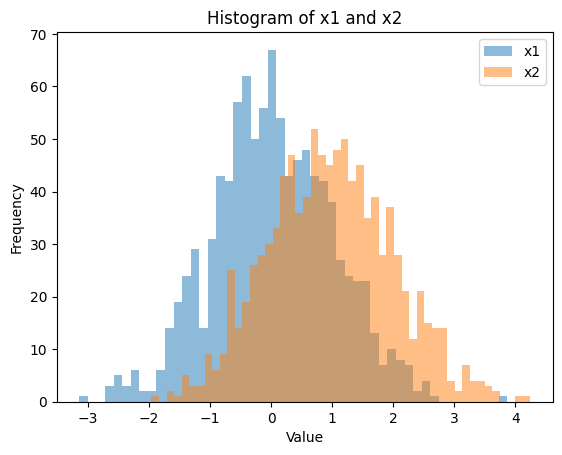

In [17]:
import matplotlib.pyplot as plt

plt.hist(x1, bins=50, alpha=0.5, label='x1')
plt.hist(x2, bins=50, alpha=0.5, label='x2')
plt.legend(loc='upper right')
plt.title('Histogram of x1 and x2')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### Different Shape Case
Here I take a uniform distribution between 0 and 1 and a Guassian distribution with zero mean and unit variance but restricted to the unit interval.

In [74]:
n = int(1e4)

x1 = Uniform(0, 1, n).sample((n,))[:, None]
x2 = MultivariateNormal(torch.zeros(1), torch.eye(1) * 1/4).sample((20 * n,))

x2 = x2[(x2 >= 0) & (x2 <= 1),None]
x2 = x2[:n,:]

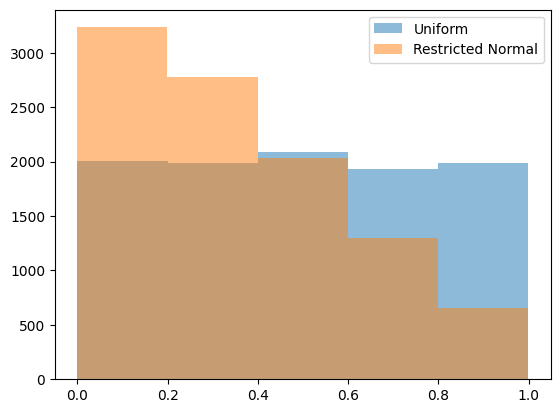

In [75]:
plt.hist(x1, bins=5, alpha=0.5, label='Uniform')
plt.hist(x2, bins=5, alpha=0.5, label='Restricted Normal')
plt.legend(loc='upper right')

In [76]:
wasserstein(x1, x2)

tensor([0.1644])

### Calibration

See how well Wasserstein captures mean distance between two Gaussians.

In [4]:
reg_values = 10.0 ** np.arange(-3, 3, 1)

results = []

for dist in [0, 1, 5]:

    x1 = MultivariateNormal(torch.zeros(1), torch.eye(1)).sample((n,))
    x2 = MultivariateNormal(torch.ones(1) * dist, torch.eye(1)).sample((n,))

    for reg in reg_values:
        # Compute the Sinkhorn distance
        P = wasserstein(x1, x2, reg=reg).item()
        
        # Print the result
        print(f"Sinkhorn distance with reg={reg} and dist={dist}: {P:.4f}")
    
        results.append((dist, reg, P))

results = np.concatenate(results).reshape(len(reg_values) * 3, 3)

/home/kenflat2/bayesian-modeling-and-inference/FlowMatching4SBI/dingo-venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/home/kenflat2/bayesian-modeling-and-inference/FlowMatching4SBI/dingo-venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


Sinkhorn distance with reg=0.001 and dist=0: 0.0000
Sinkhorn distance with reg=0.01 and dist=0: 0.0424
Sinkhorn distance with reg=0.1 and dist=0: 0.1118
Sinkhorn distance with reg=1.0 and dist=0: 0.7023
Sinkhorn distance with reg=10.0 and dist=0: 1.0693
Sinkhorn distance with reg=100.0 and dist=0: 1.1052
Sinkhorn distance with reg=0.001 and dist=1: 0.0000


/home/kenflat2/bayesian-modeling-and-inference/FlowMatching4SBI/dingo-venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/home/kenflat2/bayesian-modeling-and-inference/FlowMatching4SBI/dingo-venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 417
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


Sinkhorn distance with reg=0.01 and dist=1: 0.9248
Sinkhorn distance with reg=0.1 and dist=1: 0.9962
Sinkhorn distance with reg=1.0 and dist=1: 1.1580
Sinkhorn distance with reg=10.0 and dist=1: 1.3732
Sinkhorn distance with reg=100.0 and dist=1: 1.3990
Sinkhorn distance with reg=0.001 and dist=5: 0.0000
Sinkhorn distance with reg=0.01 and dist=5: 0.0000
Sinkhorn distance with reg=0.1 and dist=5: 5.0472
Sinkhorn distance with reg=1.0 and dist=5: 5.0472
Sinkhorn distance with reg=10.0 and dist=5: 5.0474
Sinkhorn distance with reg=100.0 and dist=5: 5.0474


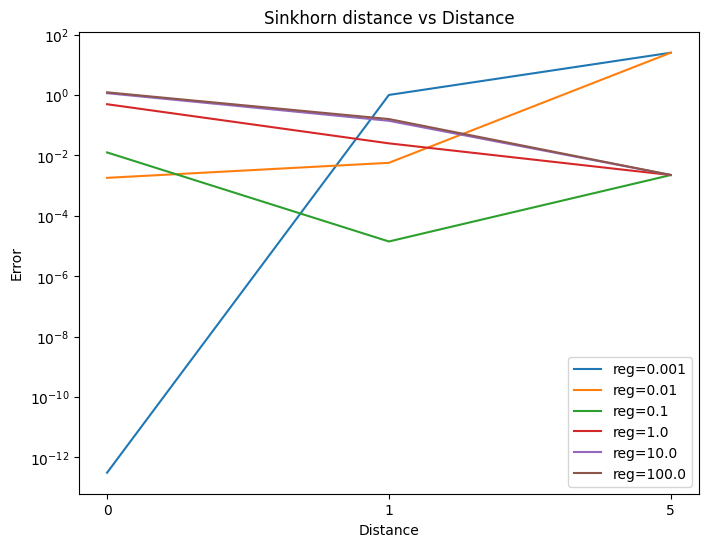

In [5]:
fig = plt.figure(figsize=(8, 6))

for reg in reg_values:
    reg_results = results[results[:, 1] == reg]

    plt.plot(np.arange(3), (reg_results[:, -1] - reg_results[:, 0])**2, label=f'reg={reg}')

plt.xlabel('Distance')
plt.ylabel('Error')
plt.yscale('log')
plt.title('Sinkhorn distance vs Distance')
plt.xticks(np.arange(3), ['0', '1', '5'])
plt.legend()

Conclusion: in this case a regularization value of 0.01 has the least error in estimating the Wasserstein distance from 1000 samples.

### Generalizing to Many Dimensions


In [15]:
dim = 5
n = 1000

x1 = MultivariateNormal(torch.zeros(dim), torch.eye(dim)).sample((n,))
x2 = MultivariateNormal(torch.ones(dim), torch.eye(dim)).sample((n,))

wasserstein(x1, x2, reg=1e-1)

tensor([2.4690])

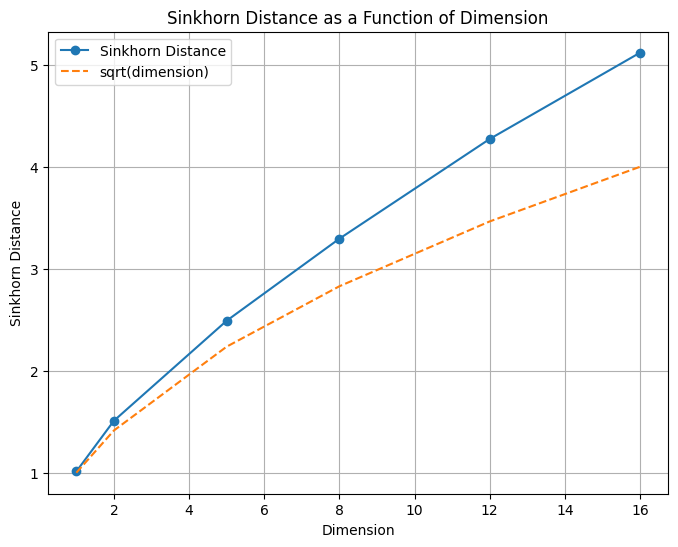

In [11]:
dims = [1, 2, 5, 8, 12, 16]
sinkhorn_distances = []

for dim in dims:
    x1 = MultivariateNormal(torch.zeros(dim), torch.eye(dim)).sample((n,))
    x2 = MultivariateNormal(torch.ones(dim), torch.eye(dim)).sample((n,))
    sinkhorn_distances.append(wasserstein(x1, x2, reg=1e-1).item())

plt.figure(figsize=(8, 6))
plt.plot(dims, sinkhorn_distances, marker='o', label='Sinkhorn Distance')
plt.plot(dims, np.sqrt(dims), linestyle='--', label='sqrt(dimension)')
plt.xlabel('Dimension')
plt.ylabel('Sinkhorn Distance')
plt.title('Sinkhorn Distance as a Function of Dimension')
plt.legend()
plt.grid()
plt.show()